In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("ggtree")
    library("readxl")
})

In [30]:
tree <- ape::read.tree("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.tre") # just 61 species
data <- read.csv("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.csv")
colnames(data) <- c("species", "feedmode", "maxtl")

stopifnot(all(data$species %in% tree$tip.label))
data <- data[match(tree$tip.label, data$species), ] # name match the dataset
stopifnot(all(data$species == tree$tip.label))

In [31]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 250) 

In [32]:
data$feedmode |> table()


   bite suction 
     31      30 

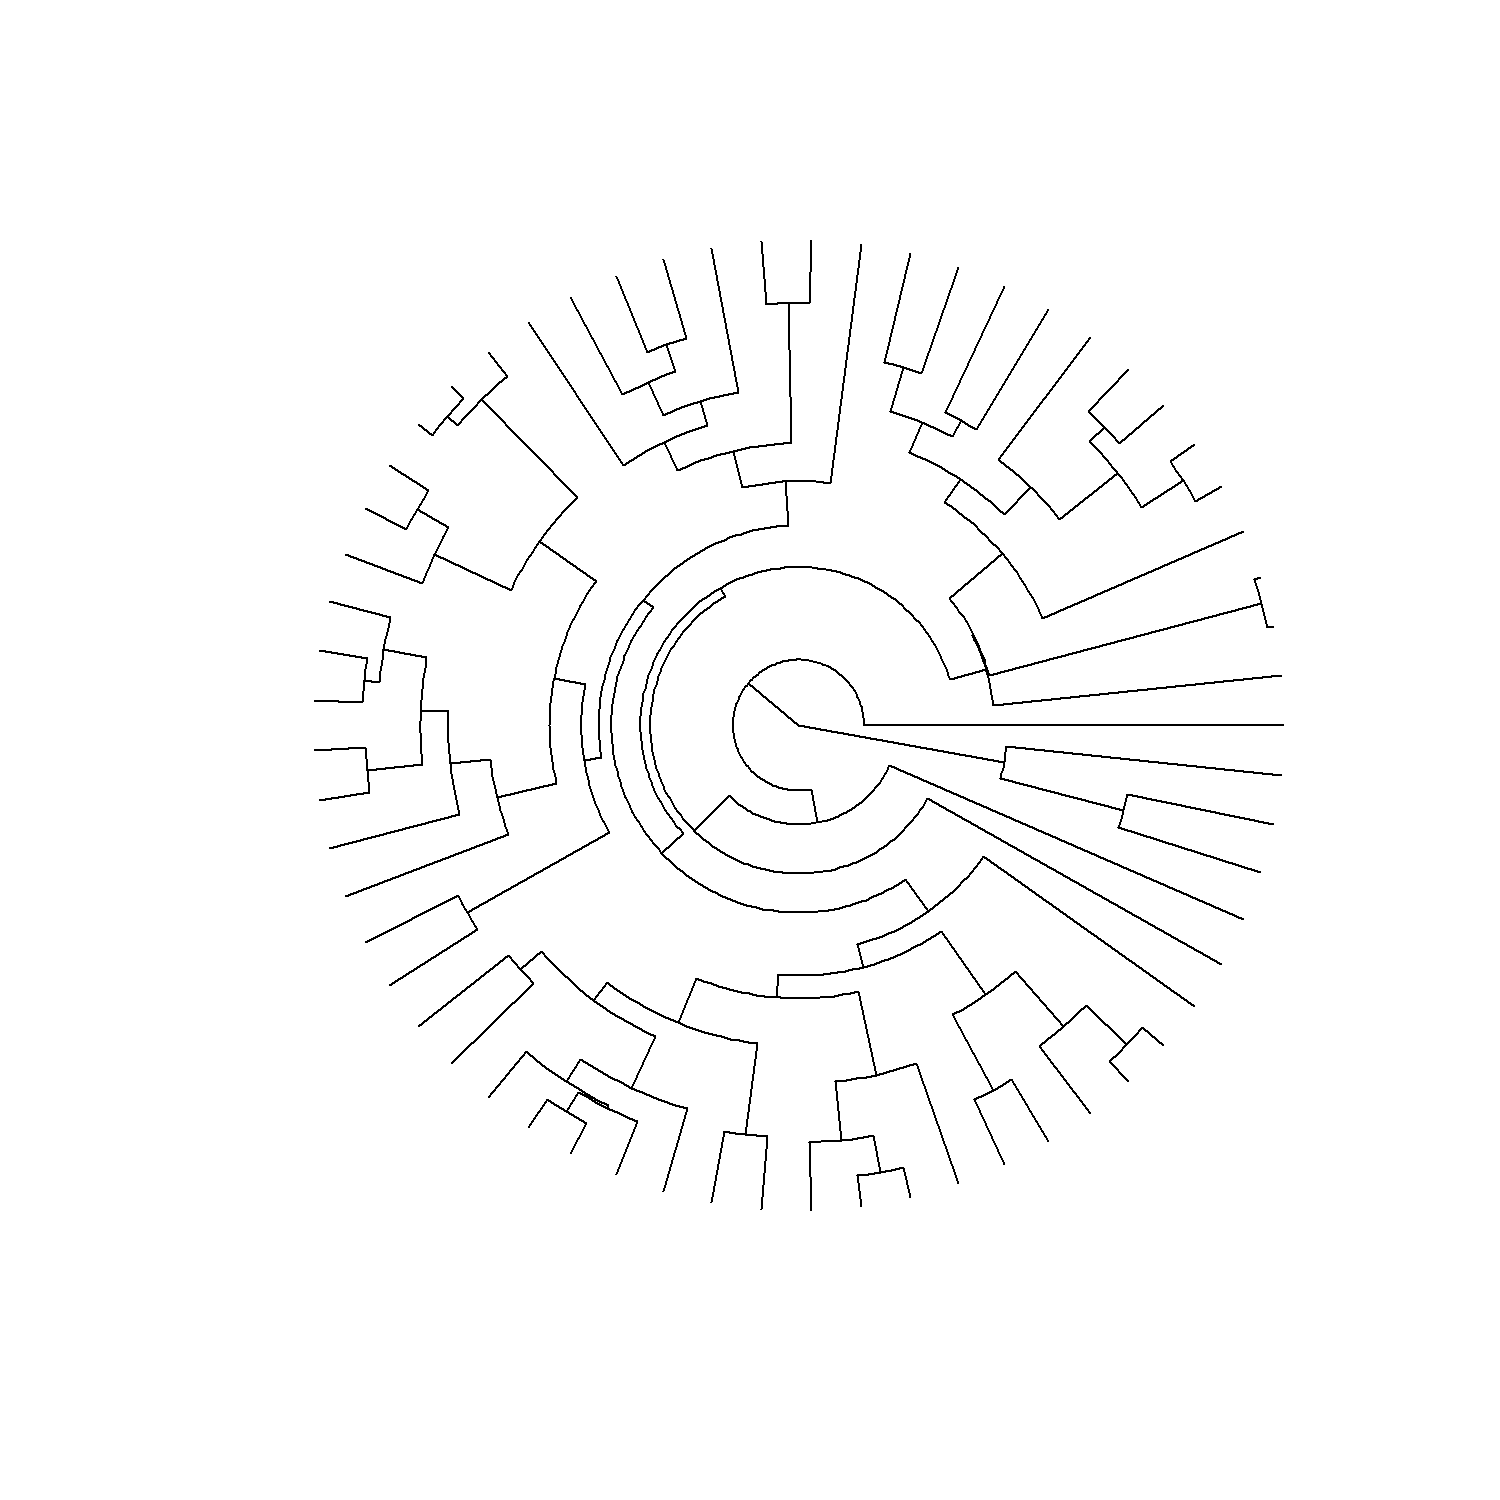

In [33]:
plot(tree, type = "fan", show.tip.label = FALSE)
ape::tiplabels(tip = data[data$feedmode == "bite", "species"], col = "red", pch=21, cex = 3)
ape::tiplabels(tip = data[data$feedmode == "suction", "species"], col = "blue", pch=21, cex = 3, adj = 1)

In [39]:
seq_along(tree$tip.label)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52 53 54 55 56 57 58 59 60 61

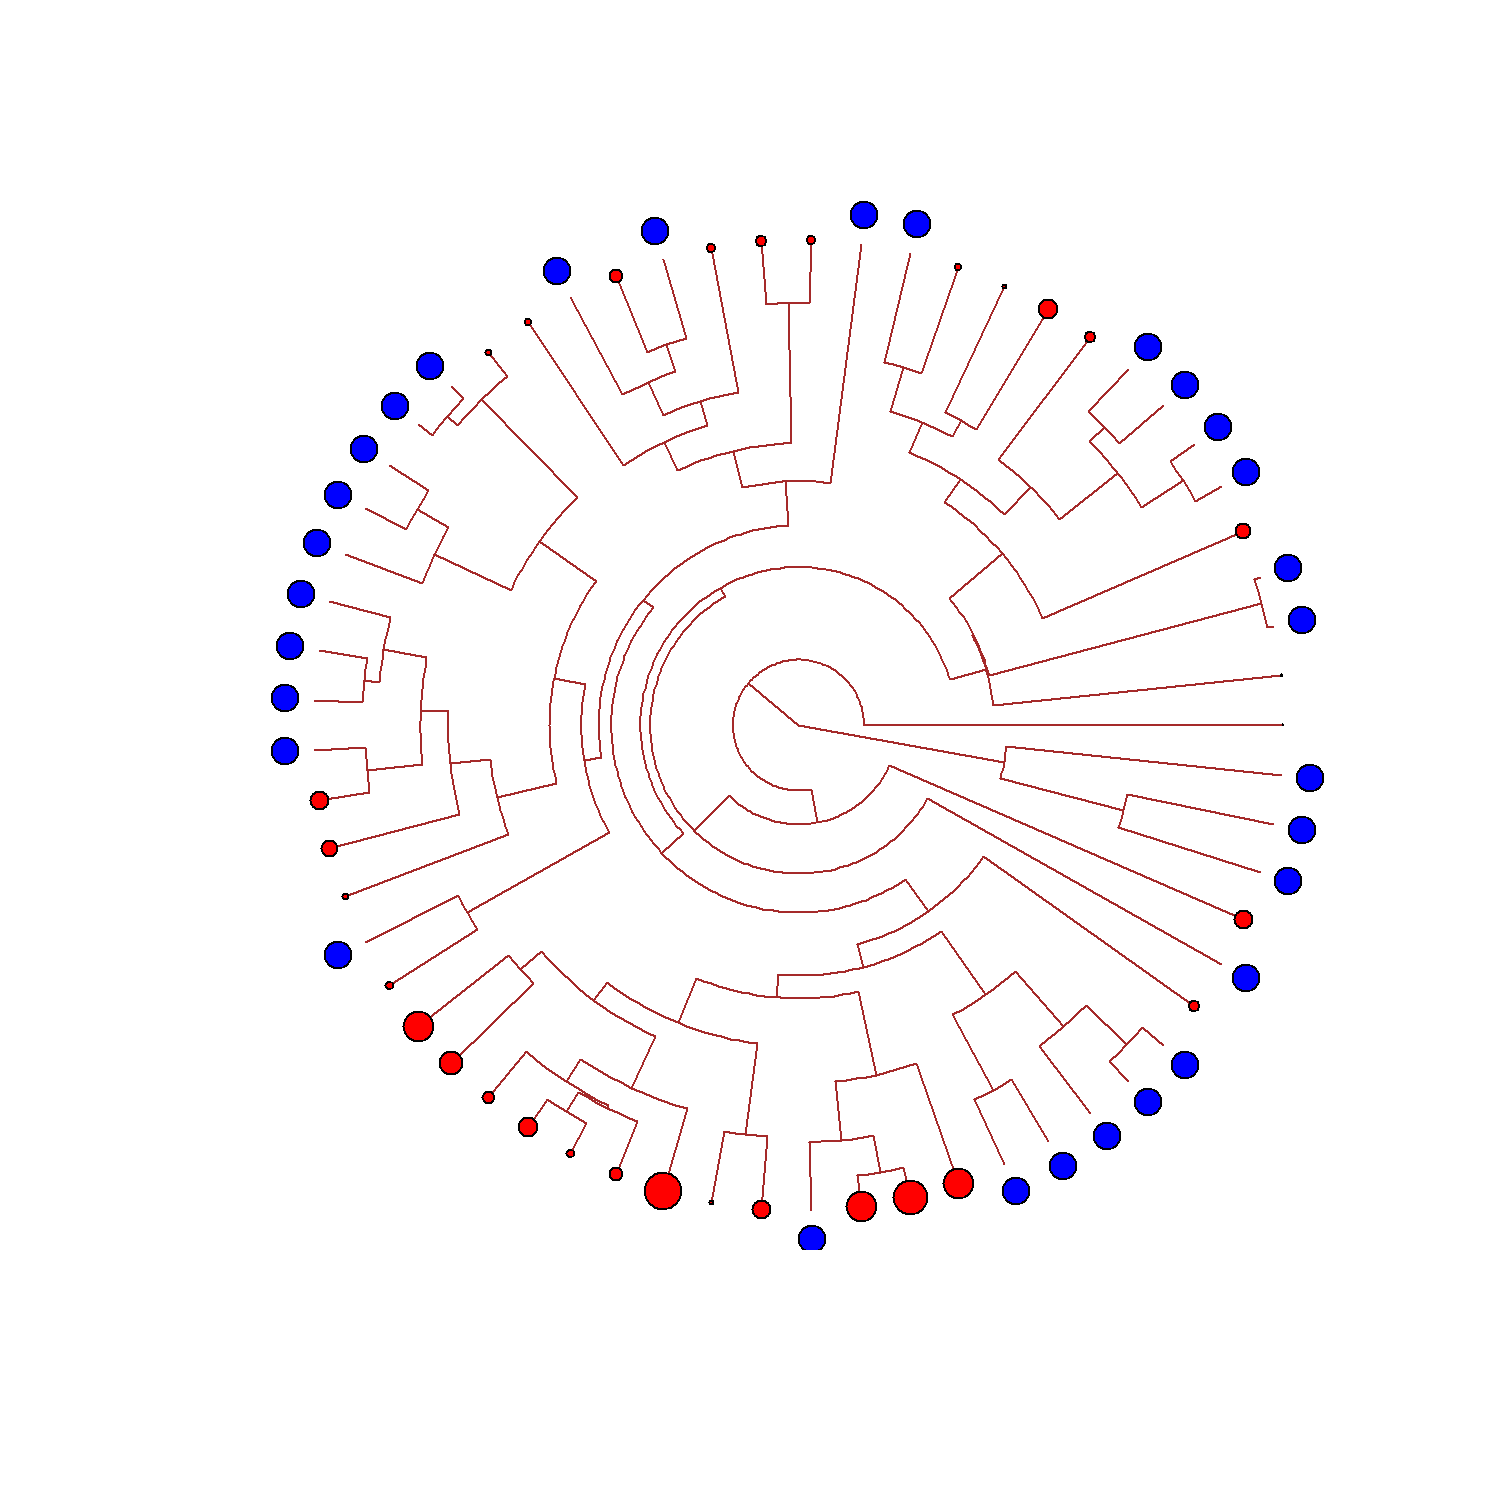

In [66]:
ape::plot.phylo(x = tree, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, edge.color = "brown")
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "bite"], bg = "red", pch=21, cex = scale(data$maxtl[data$feedmode == "bite"], center = FALSE)) # the tip argument is tip number not id!!!
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "suction"], bg = "blue", pch=21, cex = 1.5, offset = 6)

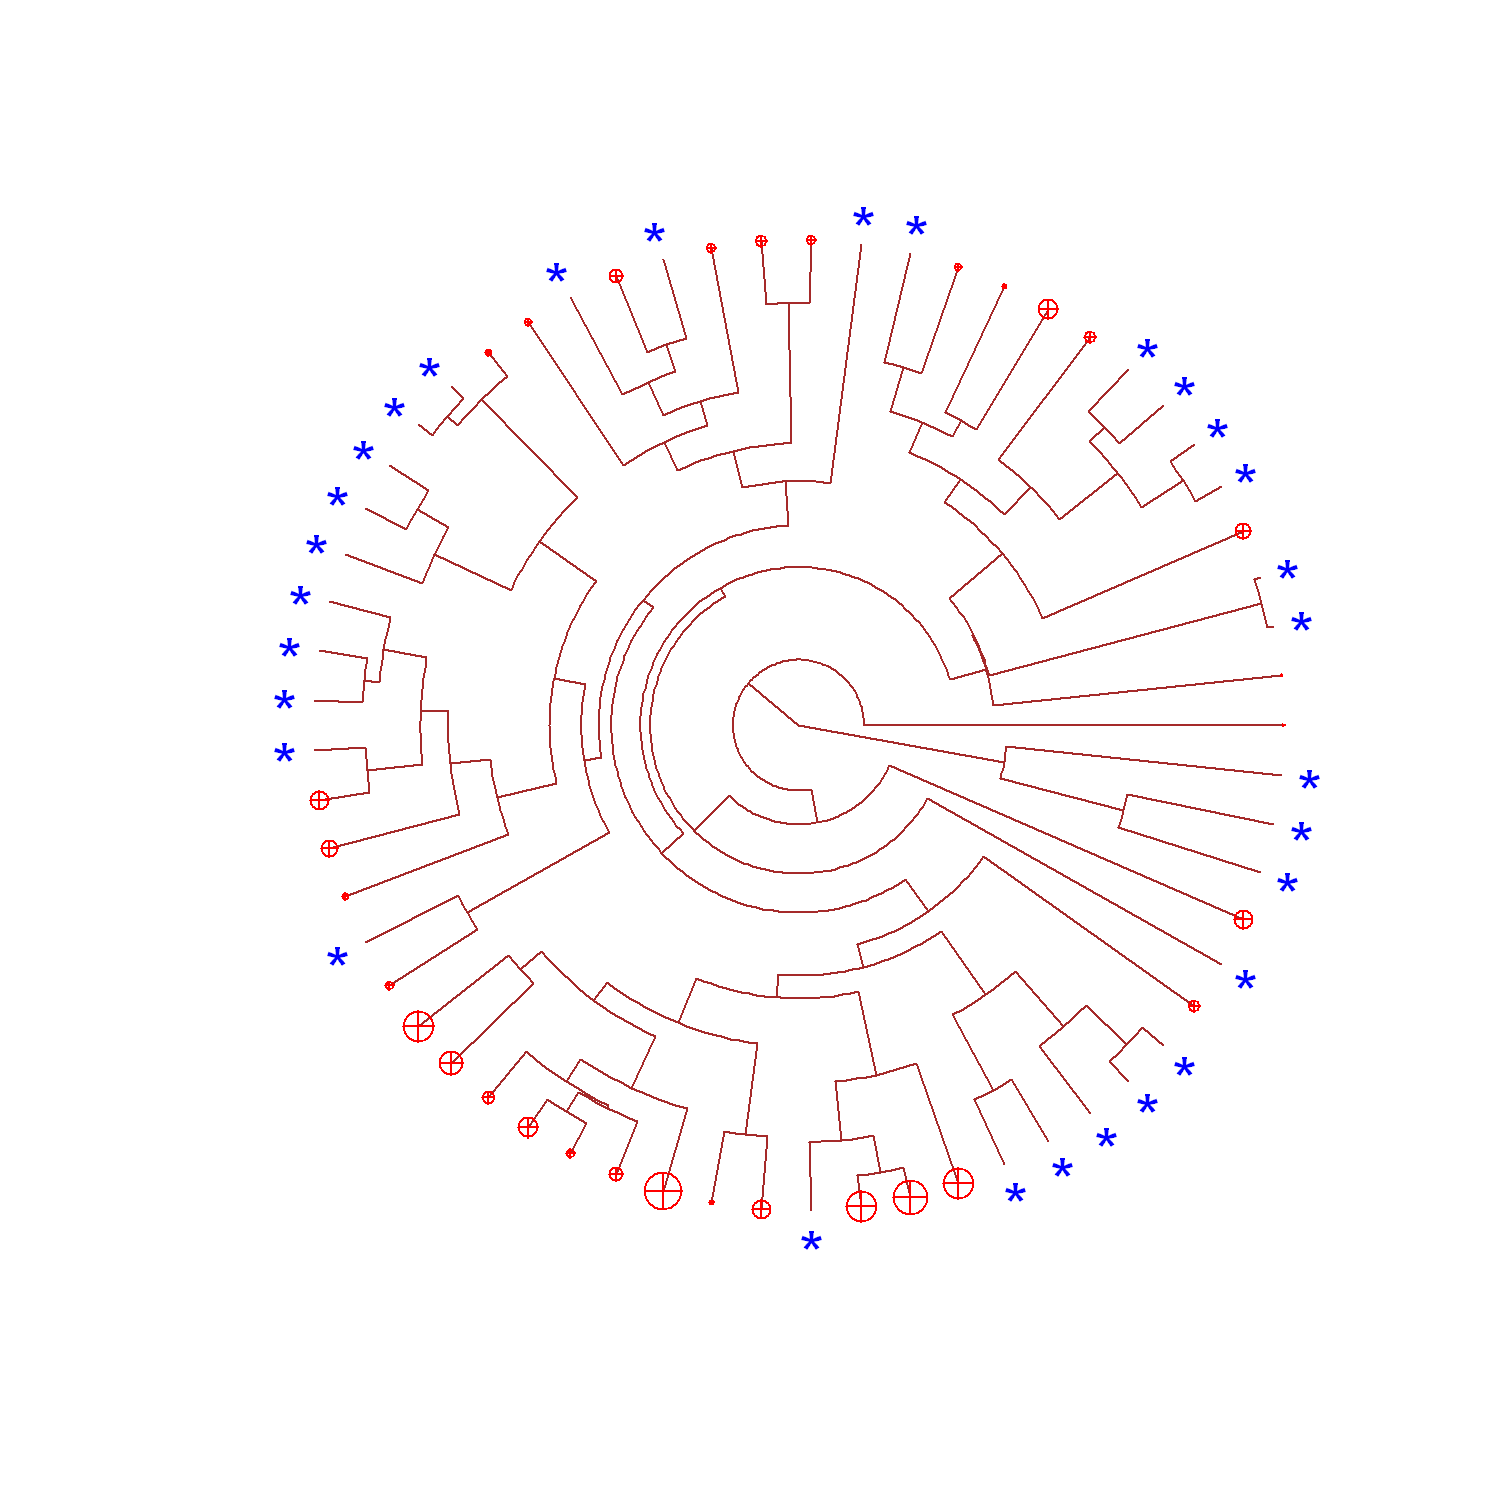

In [94]:
ape::plot.phylo(x = tree, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, edge.color = "brown")
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "bite"], col = "red", pch=10, cex = scale(data$maxtl[data$feedmode == "bite"], center = FALSE)) # the tip argument is tip number not id!!!
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "suction"], col = "blue", pch='*', cex = 1.5, offset = 6)

## ___FRED 4.0 phylogeny___
------------------

In [3]:
phylogeny <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")
data <- readxl::read_excel("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")
data$binominal <- gsub(data$binominal, pattern = ' ', replacement = '_')
stopifnot(all(data$binominal %in% phylogeny$tip.label))

data <- data[match(phylogeny$tip.label, data$binominal), ] # name match the dataset with the phylogeny
stopifnot(all(data$binominal == phylogeny$tip.label))

In [50]:
options(repr.plot.width = 15, repr.plot.height = 15)

In [72]:
# code from - https://r-graph-gallery.com/130-ring-or-donut-chart.html

doughnut <- function (x, labels = names(x), edges = 200, outer.radius = 0.8, inner.radius=0.6, clockwise = FALSE, init.angle = if (clockwise) 90 else 0, density = NULL, 
                        angle = 45, col = NULL, border = FALSE, lty = NULL, main = NULL, ...) 
                    {
    
                        if (!is.numeric(x) || any(is.na(x) | x < 0)) stop("'x' values must be positive.")
    
                        if (is.null(labels)) labels <- as.character(seq_along(x))
                        else labels <- as.graphicsAnnot(labels)
    
                        x <- c(0, cumsum(x)/sum(x))
                        dx <- diff(x)
                        nx <- length(dx)
                        
                        plot.new()
                        
                        pin <- par("pin")
                        xlim <- ylim <- c(-1, 1)
                        
                        if (pin[1L] > pin[2L]) xlim <- (pin[1L]/pin[2L]) * xlim
                        else ylim <- (pin[2L]/pin[1L]) * ylim
                        
                        plot.window(xlim, ylim, "", asp = 1)
                        if (is.null(col))
                            col <- if (is.null(density)) palette() else par("fg")
                                
                        col <- rep(col, length.out = nx)
                        border <- rep(border, length.out = nx)
                        lty <- rep(lty, length.out = nx)
                        angle <- rep(angle, length.out = nx)
                        density <- rep(density, length.out = nx)
                        twopi <- if (clockwise) -2 * pi else 2 * pi
                        
                        t2xy <- function(t, radius) {
                            t2p <- twopi * t + init.angle * pi/180
                            list(x = radius * cos(t2p), y = radius * sin(t2p))
                        }
                        
                        for (i in 1L:nx) {
                            
                            n <- max(2, floor(edges * dx[i]))
                            P <- t2xy(seq.int(x[i], x[i + 1], length.out = n),
                                      outer.radius)
                            polygon(c(P$x, 0), c(P$y, 0), density = density[i],
                                    angle = angle[i], border = border[i],
                                    col = col[i], lty = lty[i])
                            Pout <- t2xy(mean(x[i + 0:1]), outer.radius)
                            lab <- as.character(labels[i])
                            if (!is.na(lab) && nzchar(lab)) {
                                lines(c(1, 1.05) * Pout$x, c(1, 1.05) * Pout$y)
                                text(1.1 * Pout$x, 1.1 * Pout$y, labels[i],
                                     xpd = TRUE, adj = ifelse(Pout$x < 0, 1, 0),
                                     ...)
                            }
                            ## Add white disc          
                            Pin <- t2xy(seq.int(0, 1, length.out = n*nx),
                                      inner.radius)
                            polygon(Pin$x, Pin$y, density = density[i],
                                    angle = angle[i], border = border[i],
                                    col = "white", lty = lty[i])
                        }
                    
                        title(main = main, ...)
                        invisible(NULL)
}

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


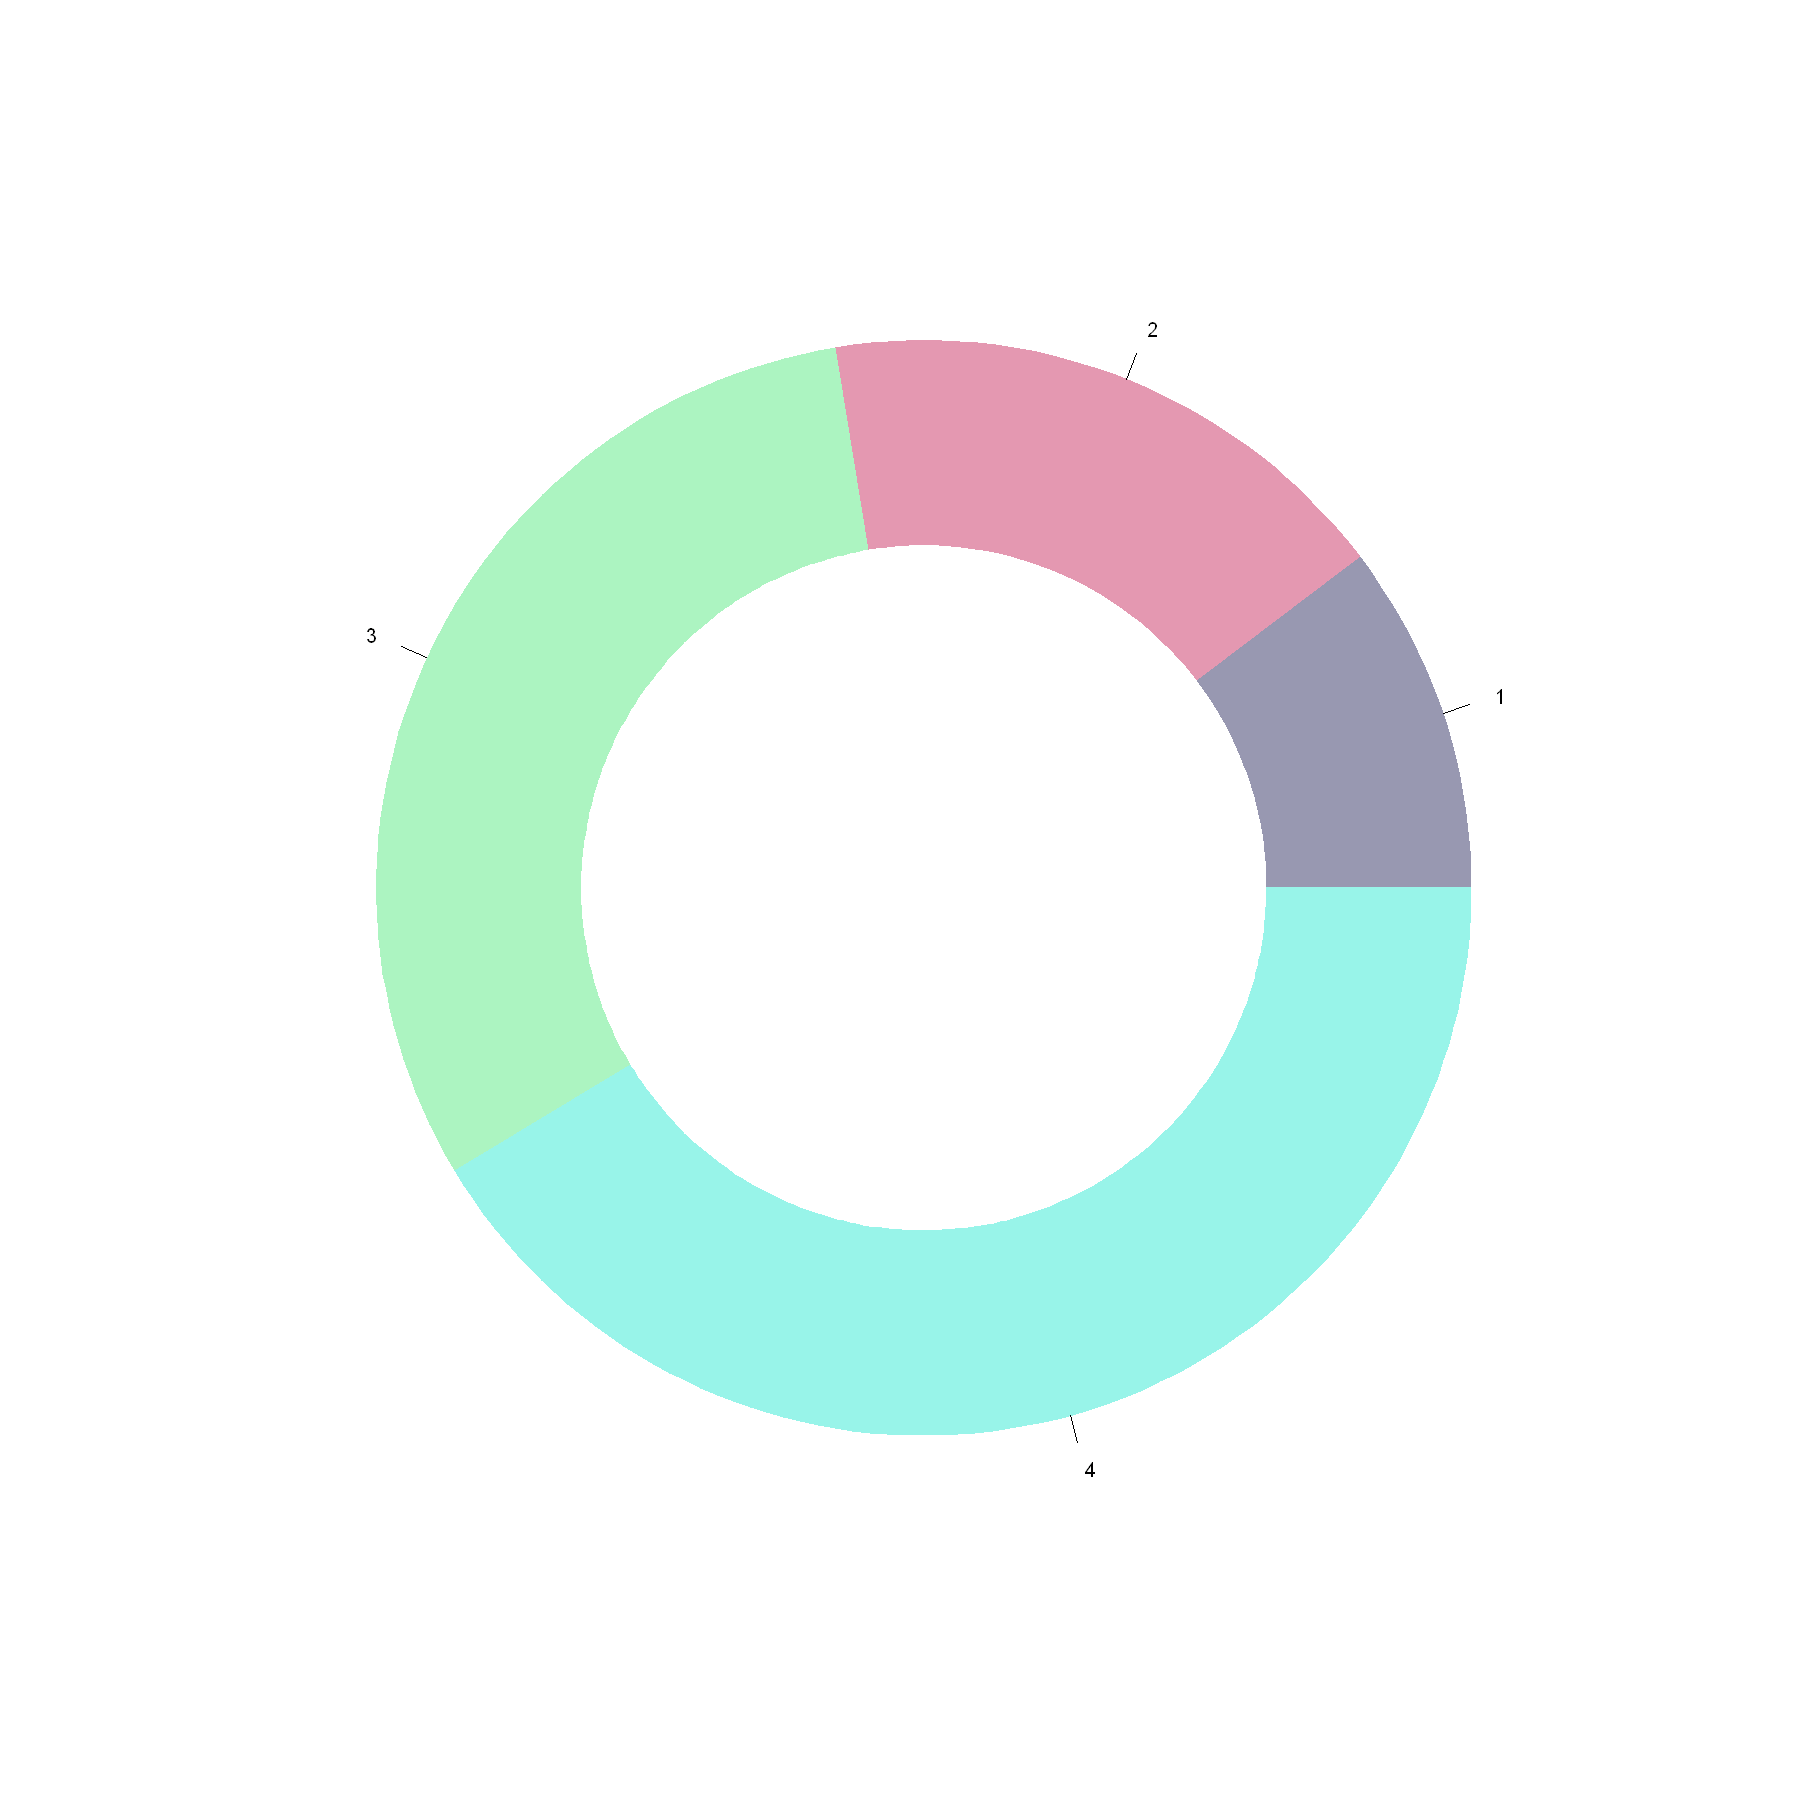

In [73]:
doughnut( c(3,5,9,12) , inner.radius=0.5, col=c(rgb(0.2,0.2,0.4,0.5), rgb(0.8,0.2,0.4,0.5), rgb(0.2,0.9,0.4,0.4) , rgb(0.0,0.9,0.8,0.4)) )

In [83]:
# data$state
ave(x = data$state, data$state, FUN = seq_along)

[1] "1"    "2"    "3"    "4"    "5"    "6"    "7"    "8"    "9"    "10"  
  [11] "11"   "12"   "13"   "14"   "15"   "16"   "17"   "18"   "19"   "20"  
  [21] "21"   "22"   "23"   "24"   "25"   "26"   "27"   "28"   "29"   "30"  
  [31] "31"   "32"   "33"   "34"   "35"   "36"   "37"   "38"   "39"   "40"  
  [41] "41"   "42"   "43"   "44"   "45"   "46"   "47"   "48"   "49"   "50"  
  [51] "51"   "52"   "53"   "54"   "55"   "56"   "57"   "58"   "59"   "60"  
  [61] "61"   "62"   "63"   "64"   "65"   "66"   "67"   "68"   "69"   "70"  
  [71] "71"   "72"   "73"   "74"   "75"   "76"   "77"   "78"   "79"   "80"  
  [81] "81"   "82"   "83"   "84"   "85"   "86"   "87"   "88"   "89"   "90"  
  [91] "91"   "92"   "93"   "94"   "95"   "96"   "97"   "98"   "99"   "100" 
 [101] "101"  "102"  "103"  "104"  "105"  "106"  "107"  "108"  "109"  "110" 
 [111] "111"  "112"  "113"  "114"  "115"  "116"  "117"  "118"  "119"  "120" 
 [121] "121"  "122"  "123"  "124"  "125"  "126"  "127"  "128"  "129"  "130" 
 [131] "131"  "132"  "133"  "134"  "135"  "136"  "137"  "138"  "139"  "140" 
 [141] "141"  "142"  "143"  "144"  "145"  "146"  "147"  "1"    "148"  "149" 
 [151] "150"  "151"  "1"    "152"  "153"  "154"  "155"  "156"  "157"  "158" 
 [161] "159"  "160"  "161"  "162"  "163"  "164"  "165"  "166"  "167"  "168" 
 [171] "169"  "170"  "171"  "172"  "173"  "174"  "175"  "176"  "177"  "178" 
 [181] "179"  "180"  "181"  "182"  "183"  "184"  "185"  "186"  "2"    "3"   
 [191] "187"  "188"  "189"  "190"  "191"  "192"  "193"  "194"  "195"  "196" 
 [201] "197"  "198"  "199"  "200"  "201"  "202"  "203"  "204"  "205"  "206" 
 [211] "207"  "208"  "209"  "210"  "211"  "212"  "213"  "214"  "215"  "216" 
 [221] "217"  "218"  "219"  "220"  "221"  "222"  "223"  "224"  "225"  "226" 
 [231] "227"  "228"  "229"  "230"  "231"  "232"  "233"  "234"  "235"  "236" 
 [241] "237"  "238"  "239"  "240"  "241"  "242"  "243"  "244"  "245"  "246" 
 [251] "247"  "248"  "249"  "250"  "1"    "2"    "3"    "4"    "5"    "6"   
 [261] "7"    "8"    "9"    "1"    "251"  "252"  "253"  "254"  "255"  "256" 
 [271] "257"  "258"  "259"  "260"  "261"  "262"  "263"  "264"  "265"  "266" 
 [281] "267"  "268"  "269"  "270"  "271"  "272"  "273"  "274"  "275"  "276" 
 [291] "277"  "278"  "279"  "280"  "281"  "282"  "4"    "283"  "284"  "285" 
 [301] "286"  "287"  "288"  "289"  "290"  "291"  "292"  "293"  "294"  "295" 
 [311] "296"  "297"  "298"  "299"  "300"  "301"  "302"  "303"  "304"  "305" 
 [321] "306"  "307"  "308"  "309"  "310"  "311"  "312"  "313"  "314"  "315" 
 [331] "316"  "317"  "318"  "319"  "320"  "321"  "5"    "6"    "7"    "322" 
 [341] "8"    "9"    "2"    "3"    "10"   "323"  "11"   "324"  "325"  "326" 
 [351] "327"  "328"  "329"  "330"  "331"  "332"  "333"  "334"  "335"  "336" 
 [361] "337"  "338"  "339"  "340"  "341"  "342"  "343"  "344"  "345"  "346" 
 [371] "347"  "348"  "349"  "350"  "351"  "352"  "353"  "354"  "355"  "356" 
 [381] "357"  "358"  "2"    "359"  "360"  "361"  "362"  "363"  "364"  "365" 
 [391] "366"  "367"  "368"  "369"  "1"    "2"    "3"    "370"  "371"  "372" 
 [401] "373"  "374"  "375"  "376"  "377"  "378"  "379"  "380"  "381"  "382" 
 [411] "383"  "384"  "385"  "386"  "387"  "388"  "389"  "390"  "391"  "392" 
 [421] "393"  "394"  "395"  "396"  "397"  "398"  "399"  "400"  "401"  "402" 
 [431] "403"  "404"  "405"  "406"  "407"  "408"  "409"  "410"  "411"  "412" 
 [441] "413"  "414"  "415"  "416"  "417"  "418"  "419"  "420"  "421"  "422" 
 [451] "423"  "424"  "425"  "426"  "427"  "428"  "429"  "430"  "431"  "432" 
 [461] "433"  "434"  "435"  "436"  "437"  "438"  "439"  "440"  "441"  "442" 
 [471] "443"  "444"  "445"  "446"  "447"  "448"  "449"  "450"  "451"  "452" 
 [481] "453"  "454"  "455"  "456"  "457"  "458"  "459"  "460"  "461"  "462" 
 [491] "463"  "464"  "465"  "466"  "467"  "468"  "469"  "470"  "471"  "472" 
 [501] "473"  "474"  "475"  "476"  "477"  "478"  "479"  "480"  "481"  "482" 
 [511] "483"  "484"  "485"  "486"  "487"  "12"   "13"   "488"  "489"  "490" 

null device 
          1

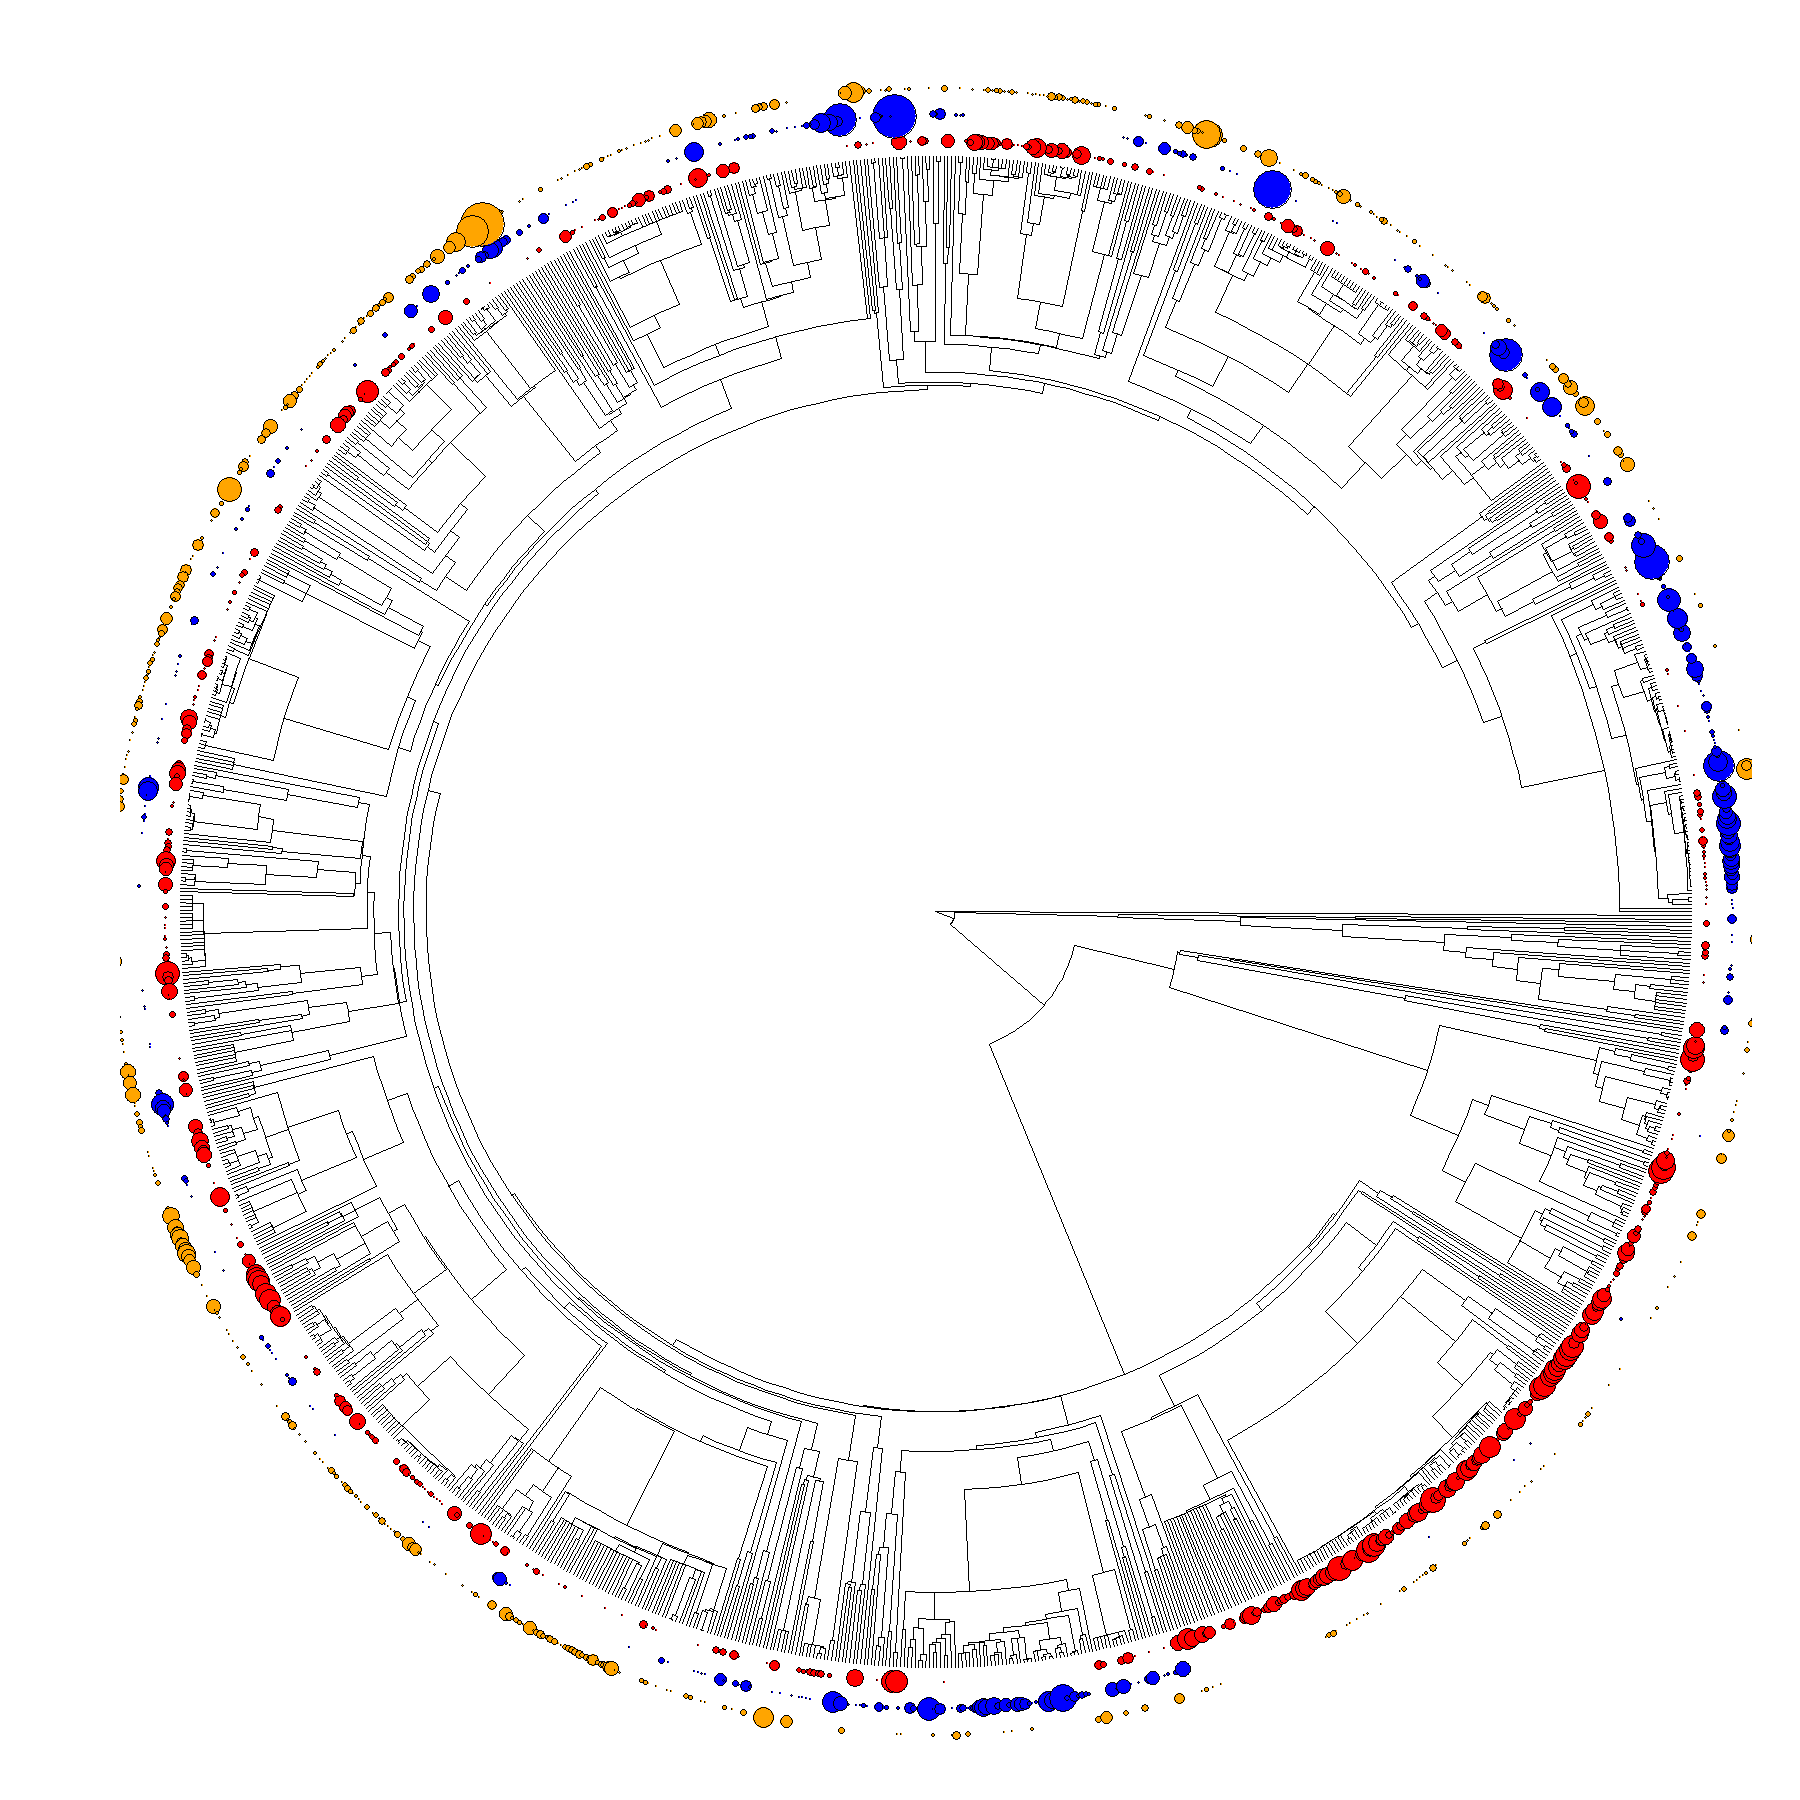

In [63]:
# png("../../plots/phylogeny.png", width = 20, height = 20, units = "in", res = 500)
par(mar = c(1, 4, 2, 1), oma = c(0, 0, 0, 0))
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)

SPACING_FIRST <- 8

# if we want to see all the species set center argument of scale() to FALSE
ape::tiplabels(bg = "red", pch = 21, cex = scale(exp(data$F00679)), offset = SPACING_FIRST) # RD
ape::tiplabels(bg = "blue", pch = 21, cex = scale(exp(data$F00727)) / 1.5, offset = SPACING_FIRST + 14) # SRL
ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 28) # RTD
dev.off()

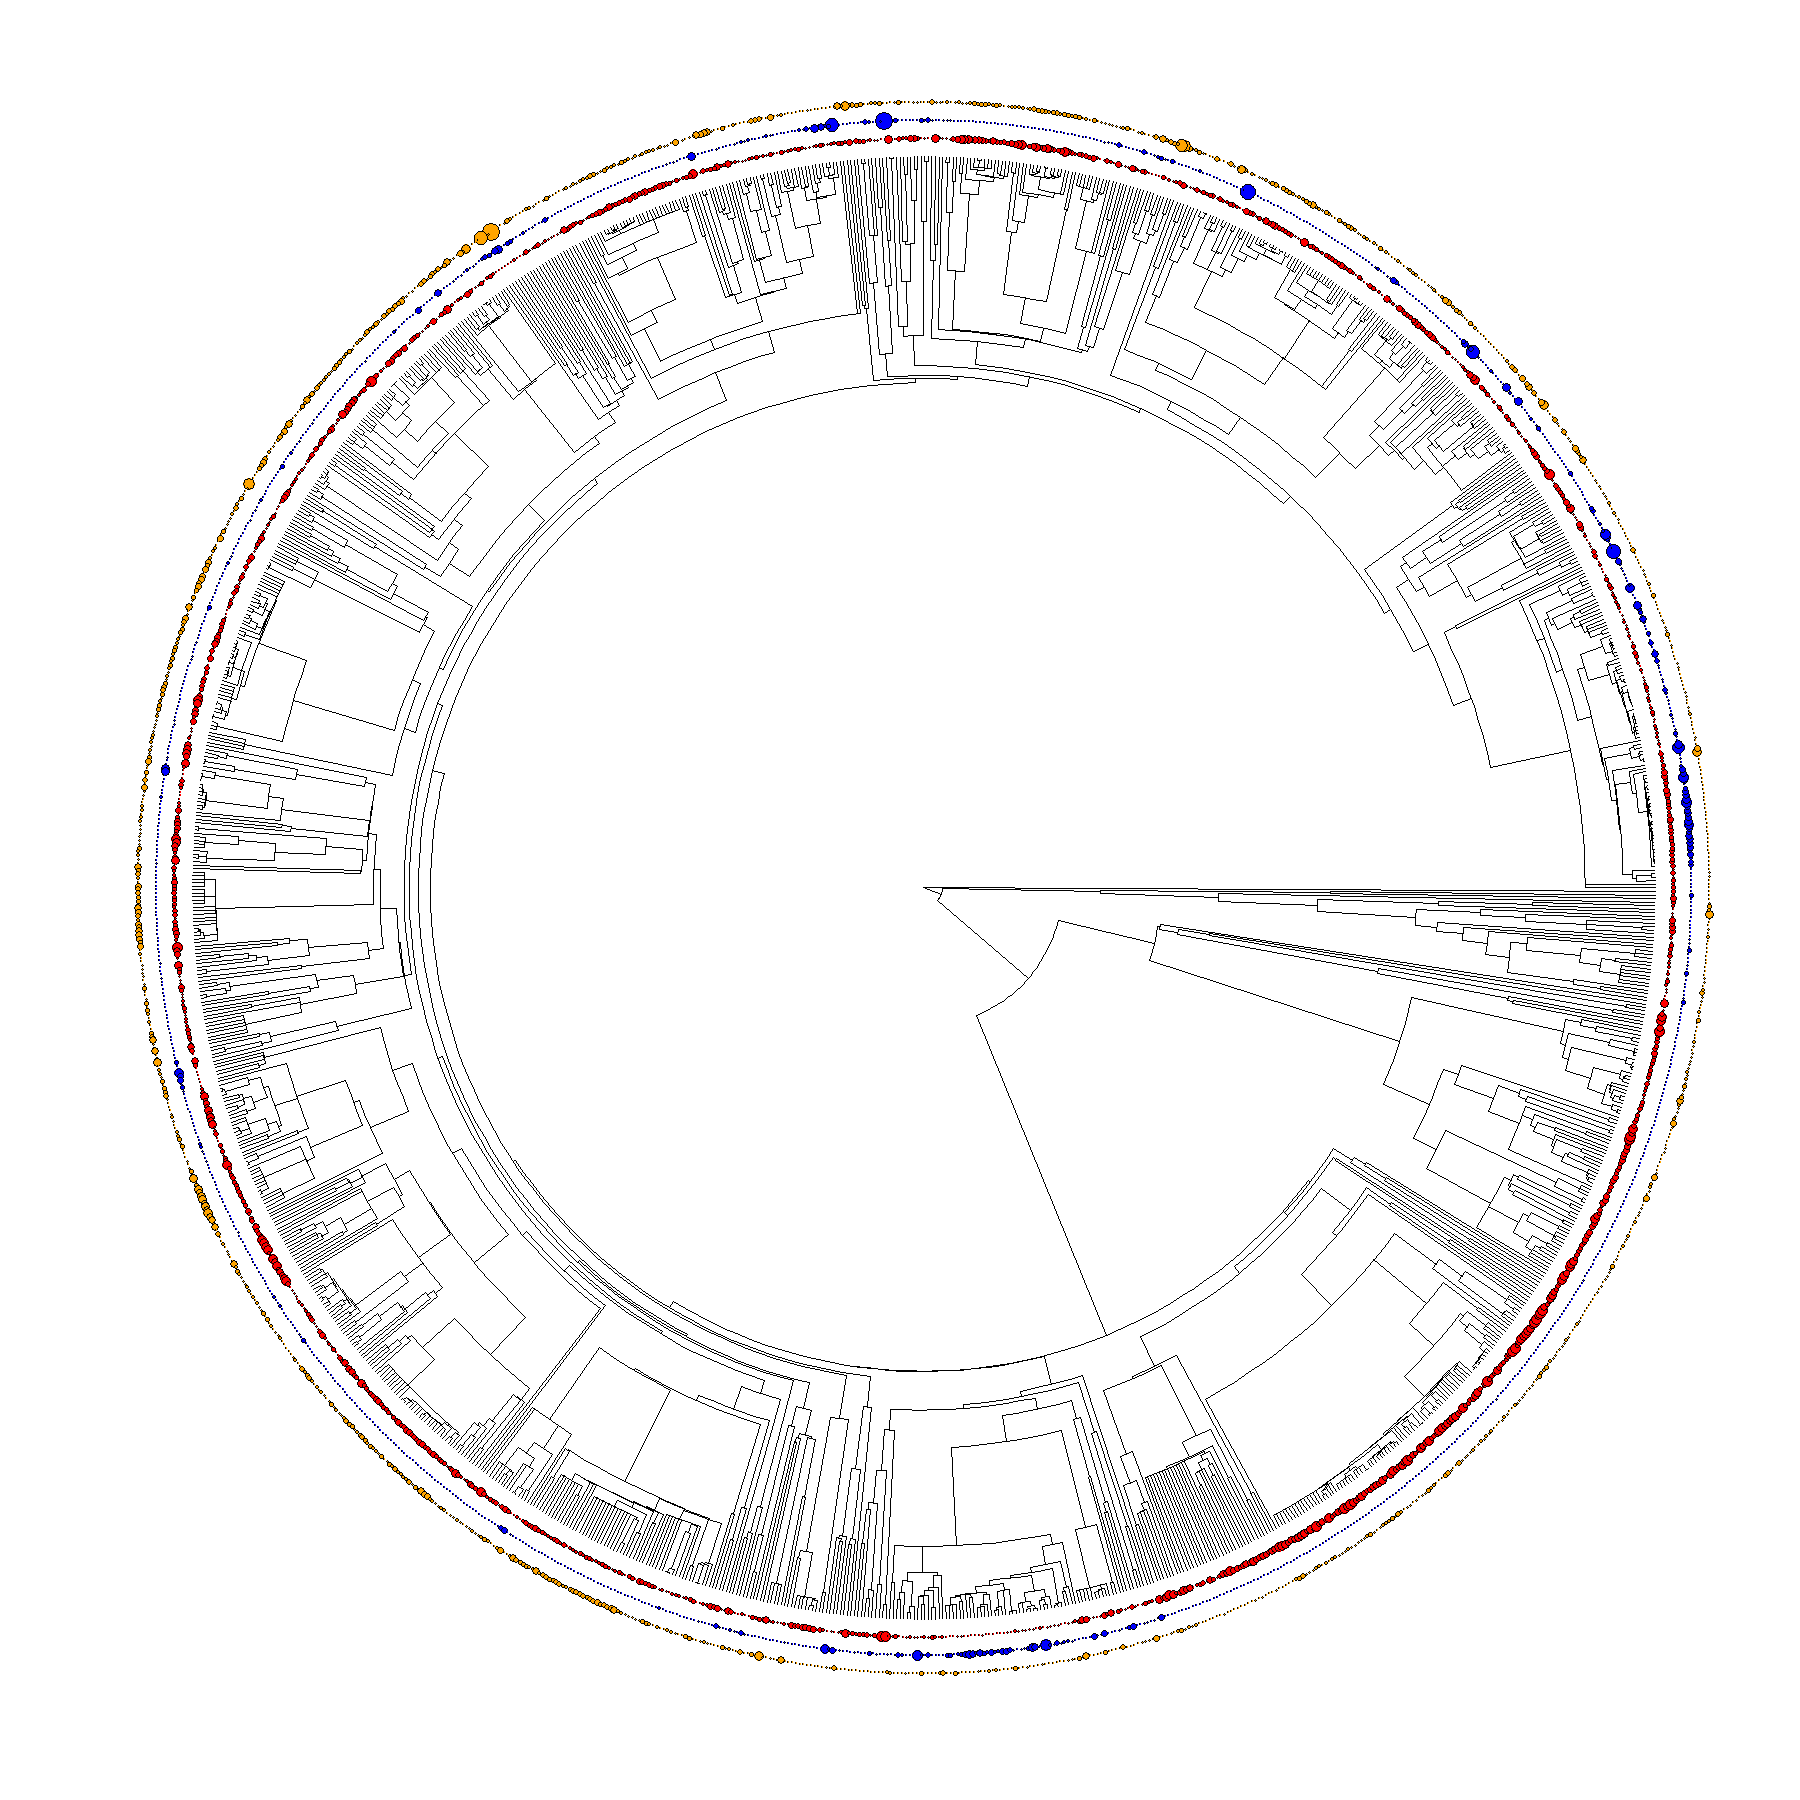

In [23]:
options(repr.plot.width = 15, repr.plot.height = 15)
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)

SPACING_FIRST <- 10.0

# if we want to see all the species set center to FALSE
ape::tiplabels(bg = "red", pch = 21, cex = exp(data$F00679) / max(exp(data$F00679)) * 1.25, offset = SPACING_FIRST) # RD
ape::tiplabels(bg = "blue", pch = 21, cex = exp(data$F00727) / max(exp(data$F00727)) * 2, offset = SPACING_FIRST + 10) # SRL
ape::tiplabels(bg = "orange", pch = 21, cex = exp(data$F00709) / max(exp(data$F00709)) * 2, offset = SPACING_FIRST + 20) # RTD